## Детали метода fit в Keras


1. Как обучаться по батчам (batch_size)
2. Как при обучении считать метрики и на тесте (validation_data)
3. Как обучаться на генераторах
4. И как визуализировать процесс обучения


Получение данных

Описание датасета:

- CRIM     per capita crime rate by town
- ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS    proportion of non-retail business acres per town
- CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX      nitric oxides concentration (parts per 10 million)
- RM       average number of rooms per dwelling
- AGE      proportion of owner-occupied units built prior to 1940
- DIS      weighted distances to five Boston employment centres
- RAD      index of accessibility to radial highways
- TAX      full-value property-tax rate per 10,000
- PTRATIO  pupil-teacher ratio by town
- B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT    % lower status of the population
- MEDV     Median value of owner-occupied homes in $1000's

In [1]:
from keras.datasets import boston_housing

(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

X_train.shape, X_test.shape

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


((404, 13), (102, 13))

In [2]:
X_train[:1]

array([[  1.23247,   0.     ,   8.14   ,   0.     ,   0.538  ,   6.142  ,
         91.7    ,   3.9769 ,   4.     , 307.     ,  21.     , 396.9    ,
         18.72   ]])

Масштабирование данных

In [3]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

mean, std

(array([3.74511057e+00, 1.14801980e+01, 1.11044307e+01, 6.18811881e-02,
        5.57355941e-01, 6.26708168e+00, 6.90106436e+01, 3.74027079e+00,
        9.44059406e+00, 4.05898515e+02, 1.84759901e+01, 3.54783168e+02,
        1.27408168e+01]),
 array([9.22929073e+00, 2.37382770e+01, 6.80287253e+00, 2.40939633e-01,
        1.17147847e-01, 7.08908627e-01, 2.79060634e+01, 2.02770050e+00,
        8.68758849e+00, 1.66168506e+02, 2.19765689e+00, 9.39946015e+01,
        7.24556085e+00]))

In [4]:
X_train -= mean
X_train /= std

X_test -= mean
X_test /= std

In [5]:
X_train.mean(axis=0)

array([-1.01541438e-16,  1.09923072e-17,  1.74337992e-15, -1.26686340e-16,
       -5.25377321e-15,  6.41414864e-15,  2.98441140e-16,  4.94653823e-16,
        1.12671149e-17, -1.98136337e-16,  2.36686358e-14,  5.95679996e-15,
        6.13920356e-16])

In [6]:
X_train.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

### Архитектура сети


Определение сети через класс Sequential и добавление слоев в него через add

In [7]:
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
tf.random.set_seed(9)


model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

### Обучение сети

In [9]:
%%time

num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 581.6882 - mae: 22.2471
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 563.6122 - mae: 21.8310 
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 543.6520 - mae: 21.3485 
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 519.3324 - mae: 20.7453 
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 488.7558 - mae: 19.9750 
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 450.3026 - mae: 18.9924 
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 402.0679 - mae: 17.7563 
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 343.6216 - mae: 16.2573 
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 277.7372 - mae: 14.4393 
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 210.0412 - mae: 12.3528 
CPU times: user 1.56 s, sys: 128 ms, total: 1.69 s
Wall time: 2.05 s


Сейчас прошло 13 батчей через сеть

#### **batch_size**
> batch_size: Integer или None.<br>
Количество сэмплов за один шаг градиентного спуска<br>
Если None, то batch_size примет дефолтное значение 32<br>
Не указывайте batch_size, если ваши данные представлены в виде генератора или keras.utils.Sequence (из-за того, что они сами генерируют данные батчами)

In [10]:
X_train.shape

(404, 13)

In [11]:
404 / 32

12.625

<img src='https://drive.google.com/uc?export=view&id=1j8SxKYEi12jzJXi_bPO28q5SV9emuu0Y'>

In [12]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=64)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 161.2025 - mae: 10.6369 
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 131.1149 - mae: 9.3934 
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 105.3256 - mae: 8.2111 
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 84.9947 - mae: 7.2347 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70.2705 - mae: 6.4699 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 60.3130 - mae: 5.9010 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 53.6799 - mae: 5.5039 
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.9583 - mae: 5.2286 
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 45.1902 - mae: 5.0070 
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 41.9031 - mae: 4.7925 
CPU times: user 514 ms, sys: 26.1 ms, total: 540 ms
Wall time: 530 ms


In [13]:
404 / 64

6.3125

In [14]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=404)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 40.0386 - mae: 4.6596
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 39.6328 - mae: 4.6307
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 39.2320 - mae: 4.6018
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 38.8369 - mae: 4.5728
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 38.4473 - mae: 4.5441
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 38.0633 - mae: 4.5156
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 37.6857 - mae: 4.4873
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 37.3147 - mae: 4.4594
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 36.9505 - mae: 4.4324
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 36.5926 - mae: 4.4058
CPU times: user 441 ms, sys: 24.1 ms, total: 465 ms
Wall time: 476 ms


#### **steps_per_epoch**

>  steps_per_epoch: Integer or `None`.<br>
        Общее количество шагов (батчей сэмплов) на одной эпохе. <br>
        Если стоит None, то steps_per_epoch равняется количеству сэмплов в датасете деленное на batch size

In [15]:
404 / 10

40.4

In [16]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          steps_per_epoch=10)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.8948 - mae: 4.2821 
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32.1275 - mae: 4.0849 
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.9778 - mae: 3.9218
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.2792 - mae: 3.7851
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.9203 - mae: 3.6760
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.8083 - mae: 3.5860
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 24.8693 - mae: 3.5102
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 24.0606 - mae: 3.4433
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 23.3530 - mae: 3.3849
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 22.7226 - mae: 3.3344
CPU times: user 426 ms, sys: 24.6 ms, total: 451 ms
Wall time: 453 ms


#### **validation_split**

> validation_split: Float между 0 и 1.<br>
        Доля обучающих данных, которая будет использоваться как валидационная часть<br>
        Модель возьмет эту долю и не будет на ней обучаться, а будет подсчитывать метрики и функцию потерь в конце каждой эпохи<br>
        Данные для валидации берутся из данных с конца в `x` и `y` **до перемешивания**.

In [17]:
404 - 81

323

In [18]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=1,
          validation_split=0.2)

Epoch 1/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.8087 - mae: 3.1491 - val_loss: 15.7562 - val_mae: 3.1555
Epoch 2/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 17.6356 - mae: 2.8439 - val_loss: 13.1930 - val_mae: 2.8842
Epoch 3/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.2181 - mae: 2.6594 - val_loss: 11.8249 - val_mae: 2.7185
Epoch 4/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.5675 - mae: 2.5226 - val_loss: 11.1355 - val_mae: 2.6036
Epoch 5/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.4654 - mae: 2.4248 - val_loss: 10.6881 - val_mae: 2.5241
Epoch 6/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.6846 - mae: 2.3554 - val_loss: 10.8167 - val_mae: 2.4970
Epoch 7/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11.1564 - mae: 2.3105 - val_loss: 10.8627 - val_mae: 2.4807
Epoch 8/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10.7380 - mae: 2.2751 - val_loss: 11.0207 - val_mae: 2.4921
Epoch 9/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 

#### **validation_data**

> validation_data: Данные, на которых считается функция потерь и метрики в конце каждой эпохи<br>
Модель не будет обучаться на этих данных


In [19]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=1,
          validation_data=(X_test, y_test))

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.8386 - mae: 2.2579 - val_loss: 22.2546 - val_mae: 3.0184
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9.5634 - mae: 2.1900 - val_loss: 21.4313 - val_mae: 2.9679
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.3189 - mae: 2.1589 - val_loss: 20.8869 - val_mae: 2.9307
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.0630 - mae: 2.1283 - val_loss: 20.4403 - val_mae: 2.8992
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.8829 - mae: 2.1056 - val_loss: 20.0213 - val_mae: 2.8664
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.7143 - mae: 2.0846 - val_loss: 19.7219 - val_mae: 2.8438
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8.5330 - mae: 2.0632 - val_loss: 19.3841 - val_mae: 2.8165
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.3456 - mae: 2.0424 - val_loss: 19.0193 - val_mae: 2.7892
Epoch 9/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/s

#### **validation_batch_size**

>validation_batch_size: Integer или `None`.<br>
        Количество сэмплов в один валидационный батч<br>
        Если None, то по дефолту равняется `batch_size`.<br>
        Не указывайте `validation_batch_size`, если ваши данные представлены в виде генератора или keras.utils.Sequence (из-за того, что они сами генерируют данные батчами)

In [20]:
X_test.shape

(102, 13)

In [21]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=1,
          validation_data=(X_test, y_test),
          validation_batch_size=X_test.shape[0])

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.9037 - mae: 1.9926 - val_loss: 18.1290 - val_mae: 2.7338
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.7791 - mae: 1.9765 - val_loss: 17.8270 - val_mae: 2.7193
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.6419 - mae: 1.9606 - val_loss: 17.6085 - val_mae: 2.7082
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.5104 - mae: 1.9431 - val_loss: 17.3280 - val_mae: 2.6961
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.4035 - mae: 1.9282 - val_loss: 17.1256 - val_mae: 2.6839
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.2915 - mae: 1.9114 - val_loss: 16.7245 - val_mae: 2.6578
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.1888 - mae: 1.9017 - val_loss: 16.6364 - val_mae: 2.6592
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.0523 - mae: 1.8845 - val_loss: 16.4617 - val_mae: 2.6624
Epoch 9/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/s

#### **validation_freq**
>validation_freq: Только нужен, если предоставлены validation data. Integer
        или `collections.abc.Container` (например, list, tuple, и др.).<br>
        Если integer, то столько эпох с обучением пройдет, до одной валидации, например, `validation_freq=2` будет запускать валидацию каждые 2 эпохи.<br>
        Если это Container, то валидация будет запущена в эти эпохи, к примеру,`validation_freq=[1, 2, 10]` запускает валидацию на 1, 2 и 10 эпохах.

In [22]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=1,
          validation_data=(X_test, y_test),
          validation_batch_size=X_test.shape[0],
          validation_freq=2)

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.7303 - mae: 1.8412
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.6191 - mae: 1.8272 - val_loss: 15.6089 - val_mae: 2.6220
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.5204 - mae: 1.8171
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.4043 - mae: 1.8028 - val_loss: 15.2445 - val_mae: 2.5988
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.3296 - mae: 1.7883
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.2390 - mae: 1.7815 - val_loss: 14.9486 - val_mae: 2.5728
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.1452 - mae: 1.7701
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.0615 - mae: 1.7567 - val_loss: 14.6811 - val_mae: 2.5662
Epoch 9/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9259 - mae: 1.7464
Epoch 10/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.8913 - mae: 1.7345 - val_loss: 14.4411 - val_mae: 2.5558

In [23]:
%%time
num_epochs = 10

model.fit(X_train, y_train,
          epochs=num_epochs,
          batch_size=1,
          validation_data=(X_test, y_test),
          validation_batch_size=X_test.shape[0],
          validation_freq=[1, 5, 10])

Epoch 1/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.7403 - mae: 1.7176 - val_loss: 14.2981 - val_mae: 2.5447
Epoch 2/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.7096 - mae: 1.7161
Epoch 3/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.6404 - mae: 1.7111
Epoch 4/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.5257 - mae: 1.6943
Epoch 5/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.4510 - mae: 1.6842 - val_loss: 13.8739 - val_mae: 2.5210
Epoch 6/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.3962 - mae: 1.6808
Epoch 7/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.3187 - mae: 1.6694
Epoch 8/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.2609 - mae: 1.6585
Epoch 9/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.2244 - mae: 1.6562
Epoch 10/10
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.1050 - mae: 1.6400 - val_loss: 13.6217 - val_mae: 2.5103
CPU times: user 5.9 s, sys: 351 ms, total: 6.26 s
Wall time: 5.22 s


### Обучение нейросети на генераторах

In [24]:
import numpy as np
from tensorflow.keras.utils import Sequence


class DataGenerator(Sequence):
    def __init__(self, data, labels, batch_size=32):
        self.batch_size = batch_size
        self.data = data
        self.labels = labels

    def __len__(self):
        return int(np.round(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        X = self.data[index * self.batch_size : (index+1) * self.batch_size]
        y = self.labels[index * self.batch_size : (index+1) * self.batch_size]

        return X, y

In [25]:
train_datagen = DataGenerator(X_train, y_train)
test_datagen = DataGenerator(X_test, y_test)

In [26]:
len(train_datagen)

13

In [27]:
len(test_datagen)

3

In [28]:
for X, y in train_datagen:
    print(X.shape)
    print(y.shape)
    break

(32, 13)
(32,)


In [29]:
404 / 32

12.625

In [30]:
%%time
num_epochs = 10

model.fit(train_datagen,
          epochs=num_epochs,
          validation_data=test_datagen)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.1109 - mae: 1.6691 - val_loss: 10.0960 - val_mae: 2.3064
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5992 - mae: 1.5595 - val_loss: 10.6594 - val_mae: 2.3907
Epoch 3/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4338 - mae: 1.5229 - val_loss: 11.0208 - val_mae: 2.4350
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3869 - mae: 1.5166 - val_loss: 10.9869 - val_mae: 2.4368
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3456 - mae: 1.5166 - val_loss: 10.9765 - val_mae: 2.4392
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3294 - mae: 1.5167 - val_loss: 10.9796 - val_mae: 2.4394
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.3077 - mae: 1.5184 - val_loss: 10.8883 - val_mae: 2.4290
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2987 - mae: 1.5149 - val_loss: 10.9636 - val_mae: 2.4344
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2772 - mae: 1.5103 - val_loss: 10.9226 - val_mae: 2.4305
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2658 - mae: 1.5128 - val_loss: 10.9958 - val_mae: 2.4382
CPU times: user 1.19 s, sys: 79.3 ms, total: 1.27 s
Wall time: 1.24 s


### History


In [31]:
%%time
num_epochs = 10

history = model.fit(train_datagen,
                    epochs=num_epochs,
                    validation_data=test_datagen)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2555 - mae: 1.5104 - val_loss: 11.0109 - val_mae: 2.4407
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2608 - mae: 1.5136 - val_loss: 11.0522 - val_mae: 2.4445
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2438 - mae: 1.5069 - val_loss: 11.0104 - val_mae: 2.4381
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2333 - mae: 1.5032 - val_loss: 11.0052 - val_mae: 2.4389
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.2254 - mae: 1.5041 - val_loss: 11.0361 - val_mae: 2.4427
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2302 - mae: 1.5086 - val_loss: 10.9633 - val_mae: 2.4329
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2212 - mae: 1.5043 - val_loss: 10.9772 - val_mae: 2.4340
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2182 - mae: 1.5044 - val_loss: 11.0246 - val_mae: 2.4401
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2094

In [32]:
history

In [33]:
history.history

{'loss': [4.255523681640625,
  4.2608466148376465,
  4.243837356567383,
  4.233333587646484,
  4.225447654724121,
  4.230212688446045,
  4.221214294433594,
  4.218210697174072,
  4.2094340324401855,
  4.216708183288574],
 'mae': [1.5104199647903442,
  1.5136080980300903,
  1.506921648979187,
  1.5031840801239014,
  1.504127860069275,
  1.5086251497268677,
  1.5043474435806274,
  1.5043760538101196,
  1.502135157585144,
  1.5043894052505493],
 'val_loss': [11.010948181152344,
  11.052159309387207,
  11.010392189025879,
  11.005210876464844,
  11.036124229431152,
  10.963345527648926,
  10.977161407470703,
  11.024611473083496,
  11.079785346984863,
  11.044803619384766],
 'val_mae': [2.4407436847686768,
  2.444532632827759,
  2.4381000995635986,
  2.438876152038574,
  2.442662239074707,
  2.432915210723877,
  2.4339568614959717,
  2.4400837421417236,
  2.4445207118988037,
  2.4441158771514893]}

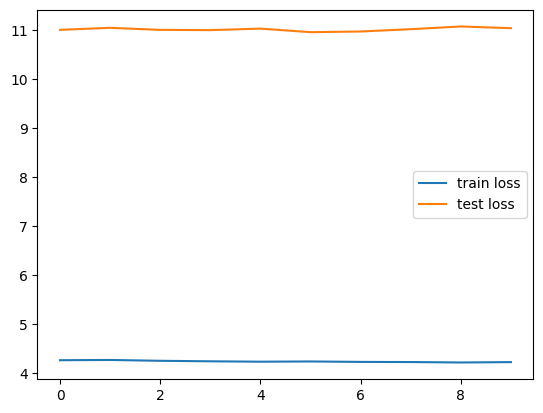

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.legend();

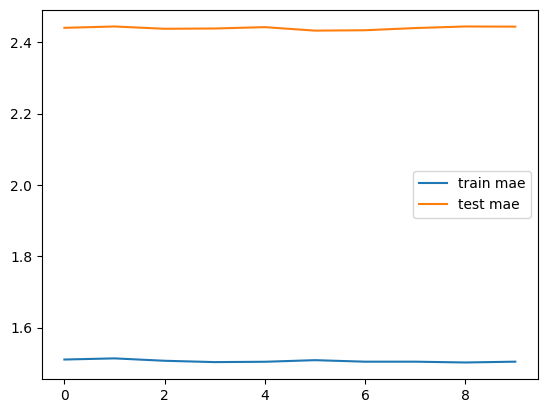

In [35]:
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='test mae')
plt.legend();